# 🚨 Fraud Detection System



## Objective

The goal of this project is to detect fraudulent credit card transactions using both supervised learning and anomaly detection techniques.


## Why is Fraud Detection Challenging?

Fraud detection is difficult because:

- Fraud cases are extremely rare compared to normal transactions
- Fraud patterns constantly evolve over time
- High false positives can annoy legitimate customers
- Missed fraud cases can lead to financial loss and reputational damage

## Project Approach

This project combines two different approaches:

### 1. Supervised Learning
- Logistic Regression

Used to detect known fraud patterns from labeled historical data.

### 2. Anomaly Detection
- Isolation Forest

Used to detect unusual or suspicious behavior that may represent new fraud patterns.

## ML Pipeline

```text
Transactions Data
        ↓
Data Cleaning
        ↓
EDA + Imbalanced Analysis
        ↓
Feature Scaling
        ↓
Logistic Regression
        ↓
Isolation Forest
        ↓
Evaluation Metrics
(Precision / Recall / F1-score / ROC-AUC)
        ↓
Business Insights


## Key Focus

This project focuses on:

- Detecting fraudulent transactions effectively
- Reducing missed fraud cases
- Understanding business tradeoffs
- Evaluating imbalanced classification problems
- Comparing supervised learning with anomaly detection approaches

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Setup & Data Loading

In this phase, we will:

- Import the required libraries
- Connect Google Drive
- Load the dataset
- Explore the structure of the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In this step, we will:

- Define the dataset path
- Load the CSV file into a pandas DataFrame
- Inspect the dataset structure

In [3]:
data_path = '/content/drive/MyDrive/creditcard.csv'

df = pd.read_csv(data_path)

df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:

df.sample(5)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
98403,66649.0,-0.955662,1.442407,-0.843942,-0.337224,2.261959,3.566417,-0.437188,0.487268,-0.698923,...,0.875509,-0.090925,-0.050840,0.990582,-0.010480,-0.306117,0.199751,0.153416,1.98,0
30939,36145.0,-2.641106,-1.335932,-1.334515,-0.870293,-2.820694,2.284134,2.858929,-3.529357,-0.859704,...,-1.471106,-0.794523,-3.793134,-0.635055,-1.229192,0.594399,0.827630,-0.093041,1548.98,0
89543,62621.0,-3.193594,-0.999196,-0.724933,-1.250224,0.244888,-1.670753,0.116604,0.644716,1.035046,...,-0.001664,0.624360,0.599767,0.118775,0.129897,-0.752030,0.489325,-0.038967,97.08,0
250636,155003.0,0.118033,0.726823,-1.680148,-1.550844,3.126377,3.212088,0.359391,0.920083,-0.160947,...,-0.335295,-0.906232,0.110467,0.592954,-0.423932,0.164172,0.245568,0.071094,1.79,0
121218,76114.0,-0.800698,1.167097,0.967080,0.004421,-0.283409,-0.371683,0.130646,0.694749,-0.654611,...,-0.136252,-0.539643,0.125302,0.136181,-0.304151,0.077803,0.121001,0.021967,15.48,0


# Dataset Inspection

In this phase, we will:

- Explore the dataset structure
- Check the number of rows and columns
- Inspect data types
- Detect missing values
- Understand the statistical summary of the dataset

In [5]:
df.shape

(284807, 31)

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


# Target Distribution Analysis

In this phase, we will:

- Analyze the distribution of fraud vs non-fraud transactions
- Understand the imbalance in the dataset
- Visualize the target variable

In [9]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


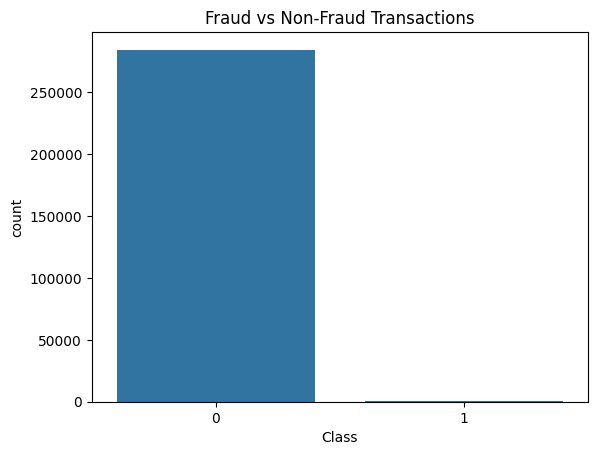

In [10]:
sns.countplot(x='Class', data=df)

plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

# Transaction Amount Analysis

In this phase, we will:

- Analyze the transaction amount distribution
- Compare fraud vs non-fraud transaction amounts
- Detect potential outliers

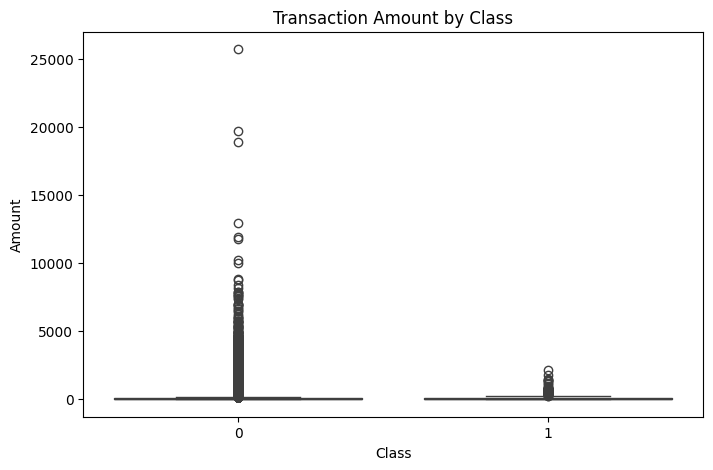

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount by Class')
plt.show()

# Correlation Analysis

In this phase, we will:

- Analyze feature relationships
- Identify features correlated with fraud
- Visualize correlations using a heatmap

In [12]:
correlation = df.corr()

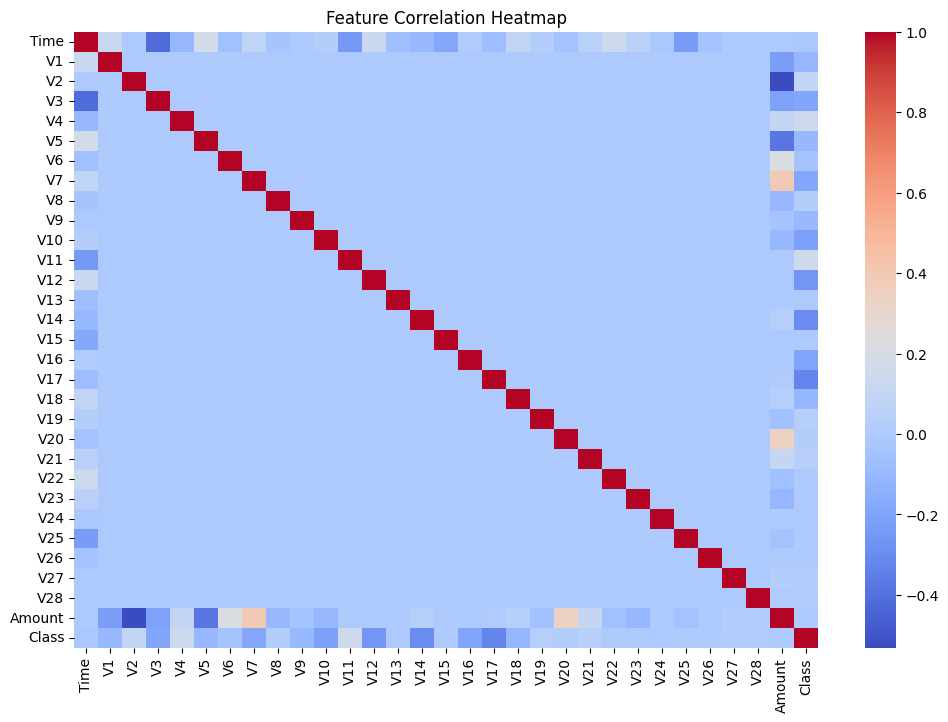

In [13]:
plt.figure(figsize=(12,8))

sns.heatmap(correlation, cmap='coolwarm')

plt.title('Feature Correlation Heatmap')
plt.show()

In [14]:
class_corr = df.corr()['Class'].sort_values()

class_corr

,Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733


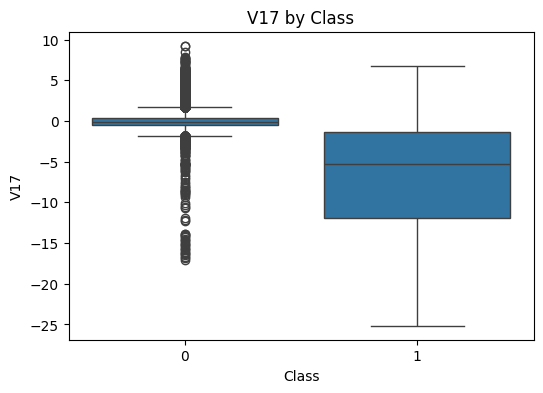

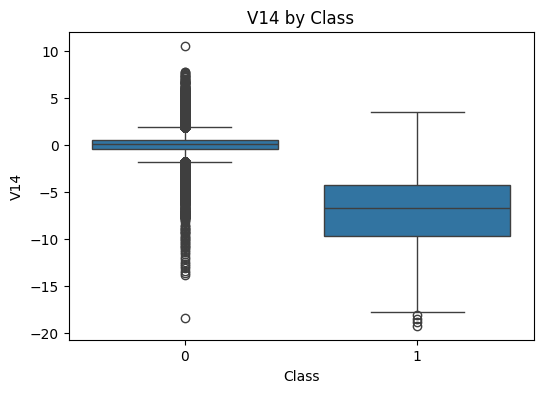

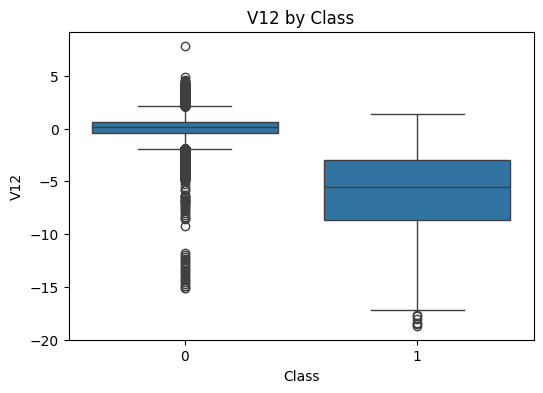

In [15]:
top_features = ['V17', 'V14', 'V12']

for feature in top_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(x='Class', y=feature, data=df)

    plt.title(f'{feature} by Class')

    plt.show()

# Preprocessing and Train/Test Split

In this phase, we will:

- Separate features from the target variable
- Split the data into training and testing sets
- Prepare the data for machine learning models

In [16]:
X = df.drop('Class', axis=1)
y = df['Class']

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [19]:
print("Original target distribution:")
print(y.value_counts(normalize=True))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Original target distribution:
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Training target distribution:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64

Testing target distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


# Feature Scaling

In this phase, we will:

- Scale numerical features
- Standardize Time and Amount
- Prevent large values from dominating the model

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scale_features = ['Time', 'Amount']

X_train_scaled[scale_features] = scaler.fit_transform(X_train[scale_features])
X_test_scaled[scale_features] = scaler.transform(X_test[scale_features])

In [22]:
X_train_scaled[['Time', 'Amount']].describe()

,Time,Amount
count,2.278450e+05,2.278450e+05
mean,-1.407707e-16,-2.020811e-17
std,1.000002e+00,1.000002e+00
min,-1.998073e+00,-3.516894e-01
25%,-8.561495e-01,-3.291944e-01
50%,-2.122647e-01,-2.639429e-01
75%,9.366285e-01,-4.262209e-02
max,1.640549e+00,1.021170e+02


# Logistic Regression Baseline Model

In this phase, we will:

- Train a baseline supervised learning model
- Use class weights to handle class imbalance
- Evaluate the model using classification metrics

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [24]:
log_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [25]:
y_pred = log_model.predict(X_test_scaled)

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [27]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[55478  1386]
 [    8    90]]


In [28]:
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.9721687370080279


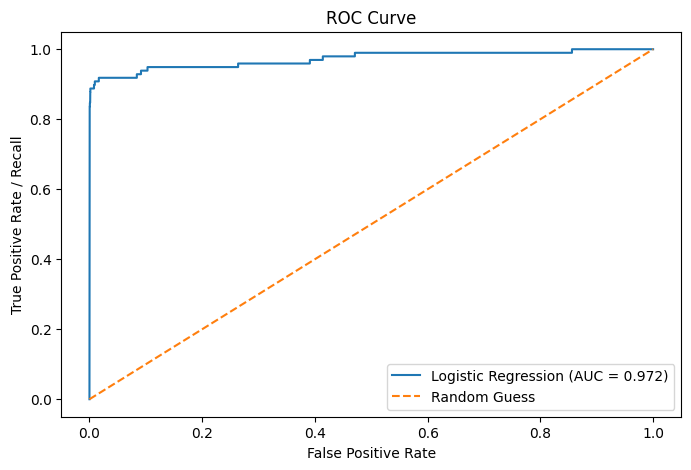

In [29]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate / Recall')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [30]:
threshold = 0.7

y_pred_threshold = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred_threshold))

cm_threshold = confusion_matrix(y_test, y_pred_threshold)
print(cm_threshold)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.12      0.91      0.21        98

    accuracy                           0.99     56962
   macro avg       0.56      0.95      0.60     56962
weighted avg       1.00      0.99      0.99     56962

[[56220   644]
 [    9    89]]


In [31]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

for t in thresholds:

    y_pred_t = (y_prob >= t).astype(int)

    report = classification_report(
        y_test,
        y_pred_t,
        output_dict=True
    )

    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print("-" * 30)

Threshold: 0.3
Precision: 0.027
Recall: 0.918
F1-score: 0.053
------------------------------
Threshold: 0.4
Precision: 0.042
Recall: 0.918
F1-score: 0.080
------------------------------
Threshold: 0.5
Precision: 0.061
Recall: 0.918
F1-score: 0.114
------------------------------
Threshold: 0.6
Precision: 0.087
Recall: 0.908
F1-score: 0.158
------------------------------
Threshold: 0.7
Precision: 0.121
Recall: 0.908
F1-score: 0.214
------------------------------
Threshold: 0.8
Precision: 0.161
Recall: 0.898
F1-score: 0.273
------------------------------


# Random Forest Model

In this phase, we will:

- Train a non-linear supervised learning model
- Handle class imbalance using class weights
- Compare its performance with Logistic Regression

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [33]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [34]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [35]:
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.952908497036969


In [36]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[56861     3]
 [   25    73]]


In [37]:
rf_thresholds = [0.2, 0.3, 0.4, 0.5]

for t in rf_thresholds:

    rf_pred_t = (rf_prob >= t).astype(int)

    report = classification_report(
        y_test,
        rf_pred_t,
        output_dict=True
    )

    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print("-" * 30)

Threshold: 0.2
Precision: 0.857
Recall: 0.857
F1-score: 0.857
------------------------------
Threshold: 0.3
Precision: 0.922
Recall: 0.847
F1-score: 0.883
------------------------------
Threshold: 0.4
Precision: 0.952
Recall: 0.806
F1-score: 0.873
------------------------------
Threshold: 0.5
Precision: 0.961
Recall: 0.745
F1-score: 0.839
------------------------------


# XGBoost Model

In this phase, we will:

- Train an advanced gradient boosting model
- Handle class imbalance using scale_pos_weight
- Compare its performance with Logistic Regression and Random Forest
- Evaluate fraud detection performance using classification metrics and ROC-AUC

Why XGBoost?

XGBoost is a boosting-based ensemble model that builds trees sequentially, where each new tree focuses on correcting the mistakes of the previous trees. It is known for strong performance on structured/tabular datasets.

In [38]:
!pip install xgboost

In [39]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1])
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [40]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [41]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.86      0.66        98

    accuracy                           1.00     56962
   macro avg       0.77      0.93      0.83     56962
weighted avg       1.00      1.00      1.00     56962



In [42]:
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.9755156951638281


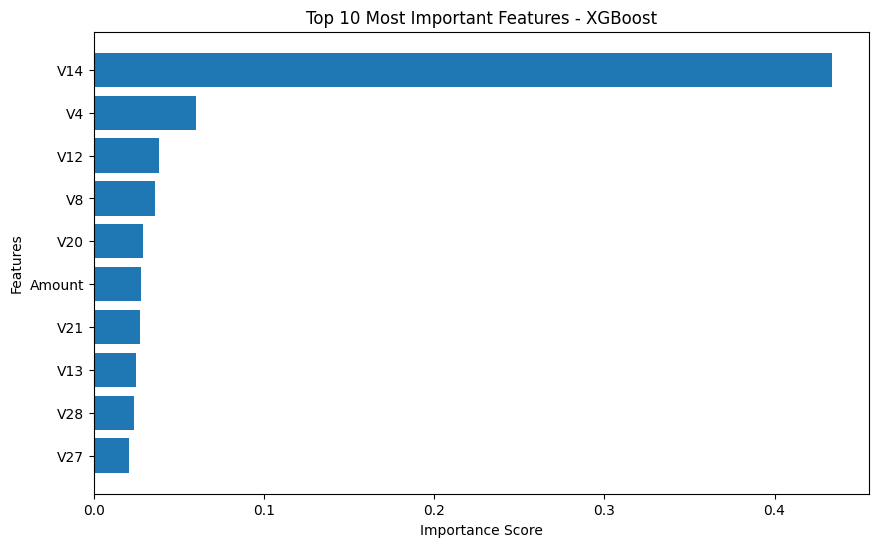

In [43]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'][:10],
    feature_importance['Importance'][:10]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features - XGBoost")

plt.gca().invert_yaxis()

plt.show()

In [44]:
xgb_thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in xgb_thresholds:

    xgb_pred_t = (xgb_prob >= t).astype(int)

    report = classification_report(
        y_test,
        xgb_pred_t,
        output_dict=True
    )

    precision = report['1']['precision']
    recall = report['1']['recall']
    f1 = report['1']['f1-score']

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print("-" * 30)

Threshold: 0.2
Precision: 0.268
Recall: 0.867
F1-score: 0.410
------------------------------
Threshold: 0.3
Precision: 0.395
Recall: 0.867
F1-score: 0.543
------------------------------
Threshold: 0.4
Precision: 0.480
Recall: 0.857
F1-score: 0.615
------------------------------
Threshold: 0.5
Precision: 0.532
Recall: 0.857
F1-score: 0.656
------------------------------
Threshold: 0.6
Precision: 0.618
Recall: 0.857
F1-score: 0.718
------------------------------


In [45]:
final_threshold = 0.6

xgb_final_pred = (
    xgb_prob >= final_threshold
).astype(int)

print(classification_report(
    y_test,
    xgb_final_pred
))

xgb_cm = confusion_matrix(
    y_test,
    xgb_final_pred
)

print(xgb_cm)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.62      0.86      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962

[[56812    52]
 [   14    84]]


In [46]:
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost (0.6 Threshold)'
    ],

    'Precision': [
        0.06,
        0.96,
        0.62
    ],

    'Recall': [
        0.92,
        0.74,
        0.86
    ],

    'F1-score': [
        0.11,
        0.84,
        0.72
    ],

    'ROC-AUC': [
        0.972,
        0.953,
        0.976
    ],

    'False Positives': [
        1386,
        3,
        52
    ],

    'False Negatives': [
        8,
        25,
        14
    ]
})

comparison

,Model,Precision,Recall,F1-score,ROC-AUC,False Positives,False Negatives
0,Logistic Regression,0.06,0.92,0.11,0.972,1386,8
1,Random Forest,0.96,0.74,0.84,0.953,3,25
2,XGBoost (0.6 Threshold),0.62,0.86,0.72,0.976,52,14


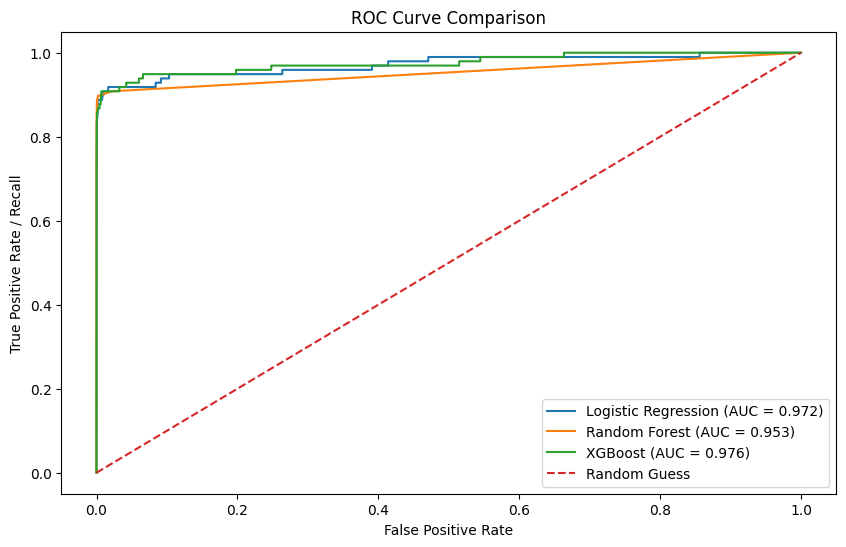

In [47]:
# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(10,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression (AUC = {roc_score:.3f})'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f'XGBoost (AUC = {xgb_auc:.3f})'
)

# Random line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate / Recall')
plt.title('ROC Curve Comparison')

plt.legend()
plt.show()

# ==========================================================
# FINAL CONCLUSION
# ==========================================================

"""
Project Conclusion:

In this project, multiple machine learning models were evaluated for fraud detection, including Logistic Regression, Random Forest, and XGBoost.

The dataset presented a strong class imbalance problem, where fraudulent transactions represented only a very small percentage of the total data. Because of this, relying only on accuracy was not appropriate, as a model could achieve very high accuracy while failing to detect fraud effectively.

Several evaluation metrics were used, including Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix, to better understand model performance from both a machine learning and business perspective.

Logistic Regression achieved strong fraud detection performance (high Recall), but produced a very large number of false positives, which could negatively impact customer experience by flagging too many legitimate transactions.

Random Forest significantly reduced false positives and achieved very high Precision, but at the cost of missing more fraudulent transactions (lower Recall), making it more conservative in fraud detection.

XGBoost provided the best overall balance between fraud detection capability and customer experience. It achieved strong Recall while maintaining better Precision and the highest ROC-AUC score among the tested models.

Additionally, threshold tuning was applied to optimize model behavior. Instead of using the default threshold of 0.5, a threshold of 0.6 was selected because it improved Precision and F1-score while maintaining nearly the same Recall performance. This reduced unnecessary fraud alerts without significantly sacrificing fraud detection capability.

Feature importance analysis also showed that some features with weaker correlation still contributed to model performance. This highlighted an important machine learning concept: low correlation does not necessarily mean a feature is unimportant, especially when models can learn non-linear relationships and feature interactions.

Overall, XGBoost with threshold tuning was selected as the final model because it offered the most balanced and practical solution for real-world fraud detection.
"""